# 05c · Prediction with patient-specific anchors

Replaces the calendar-median anchor for controls (which dropped most of them) with **each patient's own earliest visit**. DBS patients still anchored at first `dbs_date`. Re-runs the full feature+target pipeline to lift n and recompute AUC.

In [1]:
source("helpers/pain_helpers.R")
suppressPackageStartupMessages({
  library(dplyr); library(tidyr); library(ggplot2); library(purrr); library(forcats)
  library(glmnet); library(randomForest); library(xgboost); library(pROC)
})

rel <- load_full_ppmi_rel_patient_anchor()
cat("rel rows:", nrow(rel), "  patients:", dplyr::n_distinct(rel$PATNO), "\n")
feat <- build_per_patient_features(rel, var = "NP1PAIN",
                                   pre_win = c(-24, 0), post_win = c(6, 18))
cat("Patients with both windows:", nrow(feat), "\n")

rel rows: 30425   patients: 1484 


Patients with both windows: 642 


In [2]:
base_vars <- c("age_at_visit","ageonset","duration_yrs","SEX","fampd","BMI",
               "LEDD","updrs3_score","NHY","NP1DPRS","NP1ANXS","gds","stai","scopa")
base_near <- rel %>% dplyr::filter(months >= -24, months <= 0) %>%
  dplyr::arrange(PATNO, dplyr::desc(months), INFODT_orig) %>%
  dplyr::group_by(PATNO) %>% dplyr::slice_head(n = 1) %>% dplyr::ungroup() %>%
  dplyr::select(PATNO, will_receive_dbs, dplyr::any_of(base_vars))
dat <- feat %>% dplyr::inner_join(base_near, by = "PATNO")
cat("Analytic n:", nrow(dat), "\n")
print(dplyr::count(dat, will_receive_dbs, worsened, name = "n"))
save_object(dat, "patient_anchor_features")

Analytic n: 642 


# A tibble: 4 × 3
  will_receive_dbs worsened     n
  <lgl>               <int> <int>
1 FALSE                   0   485
2 FALSE                   1    90
3 TRUE                    0    56
4 TRUE                    1    11


In [3]:
median_impute <- function(x){ x[is.na(x)] <- stats::median(x, na.rm=TRUE); x }
feature_cols <- c("dbs","age_at_visit","ageonset","duration_yrs","SEX","BMI",
                  "LEDD","updrs3_score","NHY","NP1DPRS","NP1ANXS","gds","stai","scopa",
                  "pre_mean","pre_max","pre_sd","pre_last","pre_slope","pre_n")
X_df <- dat %>% dplyr::mutate(dbs = as.integer(will_receive_dbs)) %>%
  dplyr::select(dplyr::all_of(feature_cols)) %>%
  dplyr::mutate(dplyr::across(dplyr::everything(), median_impute))
X <- as.matrix(X_df); y <- dat$worsened
cat("Design:", nrow(X), "x", ncol(X), "  prevalence:", round(mean(y), 3), "\n")

Design: 642 x 20   prevalence: 0.157 


In [4]:
set.seed(42); folds <- sample(rep(seq_len(5), length.out = nrow(X)))
cv_predict <- function(fit_fn) {
  preds <- numeric(nrow(X))
  for (k in seq_len(5)) {
    te <- which(folds == k); tr <- setdiff(seq_len(nrow(X)), te)
    preds[te] <- fit_fn(X[tr,,drop=FALSE], y[tr], X[te,,drop=FALSE])
  }
  preds
}
fit_enet <- function(Xtr,ytr,Xte){ cv <- glmnet::cv.glmnet(Xtr,ytr,family="binomial",alpha=0.5,nfolds=5); as.numeric(predict(cv,newx=Xte,s="lambda.min",type="response")) }
fit_rf   <- function(Xtr,ytr,Xte){ m <- randomForest::randomForest(x=Xtr,y=factor(ytr,levels=c(0,1)),ntree=500,nodesize=5); as.numeric(predict(m,Xte,type="prob")[,"1"]) }
fit_xgb  <- function(Xtr,ytr,Xte){ dtr <- xgboost::xgb.DMatrix(Xtr,label=ytr); m <- xgboost::xgb.train(params=list(objective="binary:logistic",eta=0.05,max_depth=4,subsample=0.8,colsample_bytree=0.8,verbosity=0),data=dtr,nrounds=400,verbose=0); as.numeric(predict(m,Xte)) }
set.seed(42); p_enet <- cv_predict(fit_enet)
set.seed(42); p_rf   <- cv_predict(fit_rf)
set.seed(42); p_xgb  <- cv_predict(fit_xgb)
metrics <- function(name,p,y){ auc <- suppressMessages(as.numeric(pROC::auc(pROC::roc(y,p,quiet=TRUE)))); tibble::tibble(model=name, AUC=auc, Brier=mean((p-y)^2)) }
res <- dplyr::bind_rows(metrics("Elastic Net",p_enet,y), metrics("Random Forest",p_rf,y), metrics("XGBoost",p_xgb,y), metrics("Naive",rep(mean(y),length(y)),y))
print(res); save_table(res,"prediction_patient_anchor_metrics")

# A tibble: 4 × 3
  model           AUC Brier
  <chr>         <dbl> <dbl>
1 Elastic Net   0.574 0.131
2 Random Forest 0.568 0.137
3 XGBoost       0.532 0.151
4 Naive         0.5   0.133


# A tibble: 6 × 3
  model                       AUC Brier
  <chr>                     <dbl> <dbl>
1 Elastic Net · DBS         0.508 0.139
2 Random Forest · DBS       0.623 0.155
3 XGBoost · DBS             0.581 0.164
4 Elastic Net · Never-DBS   0.586 0.131
5 Random Forest · Never-DBS 0.586 0.134
6 XGBoost · Never-DBS       0.546 0.150


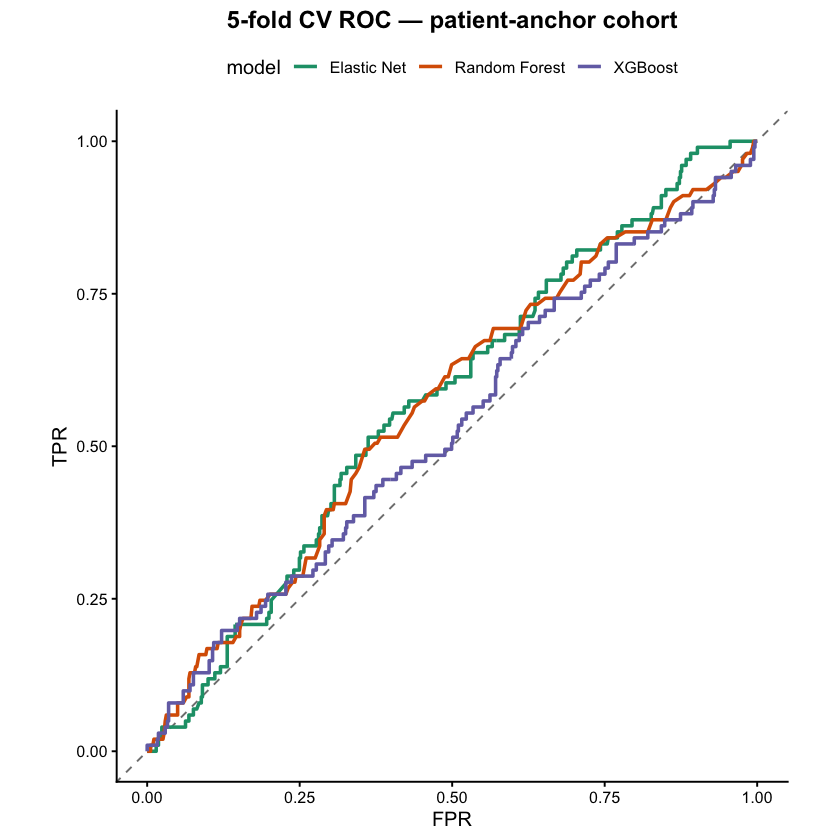

In [5]:
dbs_idx <- dat$will_receive_dbs
sub <- dplyr::bind_rows(
  metrics("Elastic Net · DBS", p_enet[dbs_idx], y[dbs_idx]),
  metrics("Random Forest · DBS", p_rf[dbs_idx], y[dbs_idx]),
  metrics("XGBoost · DBS", p_xgb[dbs_idx], y[dbs_idx]),
  metrics("Elastic Net · Never-DBS", p_enet[!dbs_idx], y[!dbs_idx]),
  metrics("Random Forest · Never-DBS", p_rf[!dbs_idx], y[!dbs_idx]),
  metrics("XGBoost · Never-DBS", p_xgb[!dbs_idx], y[!dbs_idx]))
print(sub); save_table(sub,"prediction_patient_anchor_subgroup")

roc_df <- purrr::map_dfr(list(`Elastic Net`=p_enet,`Random Forest`=p_rf,XGBoost=p_xgb),
  function(p){ r <- pROC::roc(y,p,quiet=TRUE); tibble::tibble(fpr=1-r$specificities,tpr=r$sensitivities) }, .id="model")
p_roc <- ggplot(roc_df,aes(fpr,tpr,colour=model)) + geom_abline(slope=1,linetype="dashed",colour="grey50") + geom_path(linewidth=1) +
  scale_colour_brewer(palette="Dark2") + coord_equal() +
  labs(title="5-fold CV ROC — patient-anchor cohort",x="FPR",y="TPR") +
  theme_classic(base_size=12) + theme(plot.title=element_text(face="bold",hjust=0.5),legend.position="top")
p_roc; save_fig(p_roc,"Fig11c_roc_patient_anchor",width=5.5,height=5.5)

# A tibble: 20 × 5
   feature         `0`    `1` MeanDecreaseAccuracy MeanDecreaseGini
   <chr>         <dbl>  <dbl>                <dbl>            <dbl>
 1 ageonset     18.5   -4.16                17.9             18.5  
 2 duration_yrs  3.50   1.45                 3.85            17.9  
 3 BMI           0.659 -3.21                -0.796           17.8  
 4 age_at_visit 18.8   -7.92                17.3             17.1  
 5 updrs3_score -4.48   0.310               -3.98            13.4  
 6 stai          8.00  -2.30                 6.84            11.1  
 7 scopa         1.64  -4.86                -0.676            8.91 
 8 pre_slope     3.78  -1.24                 3.03             8.88 
 9 LEDD          6.97  -6.83                 3.88             7.19 
10 pre_n         8.38  -5.52                 5.69             7.16 
11 pre_mean     16.9   -3.77                16.9              6.93 
12 gds           9.87  -3.67                 8.25             6.82 
13 pre_sd        8.67  -4.61 

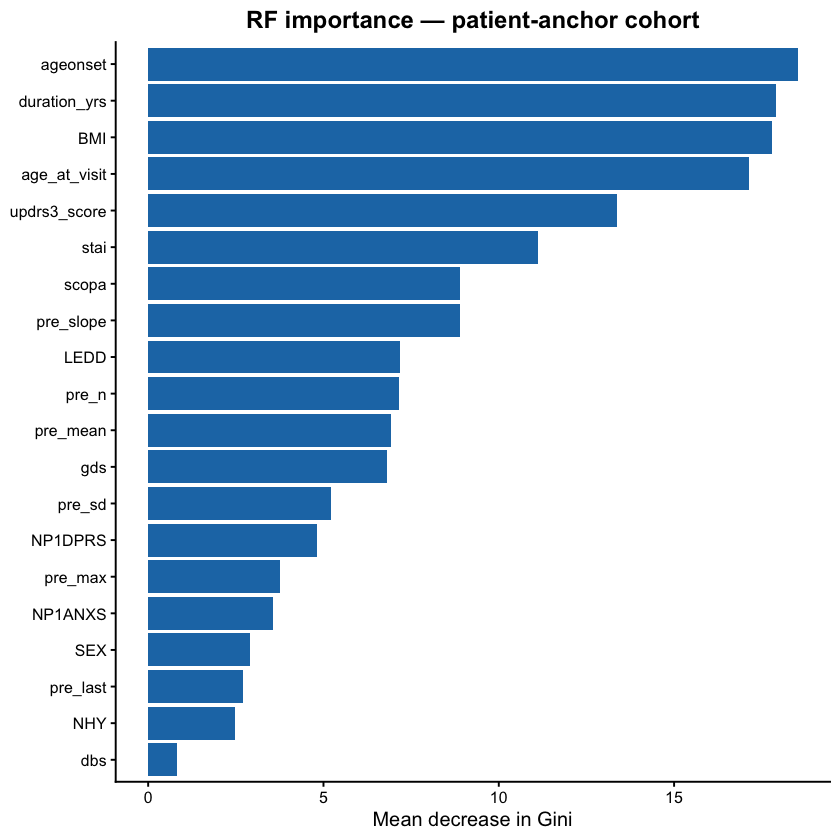

In [6]:
set.seed(42)
rf <- randomForest::randomForest(x=X, y=factor(y,levels=c(0,1)), ntree=1000, importance=TRUE)
imp <- tibble::as_tibble(randomForest::importance(rf), rownames="feature") %>%
  dplyr::arrange(dplyr::desc(MeanDecreaseGini))
print(imp, n=30)
save_table(imp,"rf_importance_patient_anchor")
p_imp <- ggplot(imp %>% dplyr::mutate(feature=forcats::fct_reorder(feature,MeanDecreaseGini)),
                aes(MeanDecreaseGini,feature)) + geom_col(fill="#1f78b4") +
  labs(title="RF importance — patient-anchor cohort",x="Mean decrease in Gini",y=NULL) +
  theme_classic(base_size=12) + theme(plot.title=element_text(face="bold",hjust=0.5))
p_imp; save_fig(p_imp,"Fig12c_rf_importance_patient_anchor",width=6.5,height=6)